---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** 조윤성 &nbsp; **학번:** 20230085 &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem

In [12]:
df = pd.read_excel('acute_oral.xlsx', sheet_name='Data')

df = df[(df['Endpoint']=='LD50') & (df['Mixture']=='Chemical') & df['SMILES'].notna()]
#LD50, 단일화합물만 사용

df = df.groupby('CASRN').agg(
    LD50_median=('Response','median'),
    SMILES=('SMILES','first'),
    Chemical_Name=('Chemical_Name','first')
).reset_index()

print('화합물 수:', len(df))

화합물 수: 8794


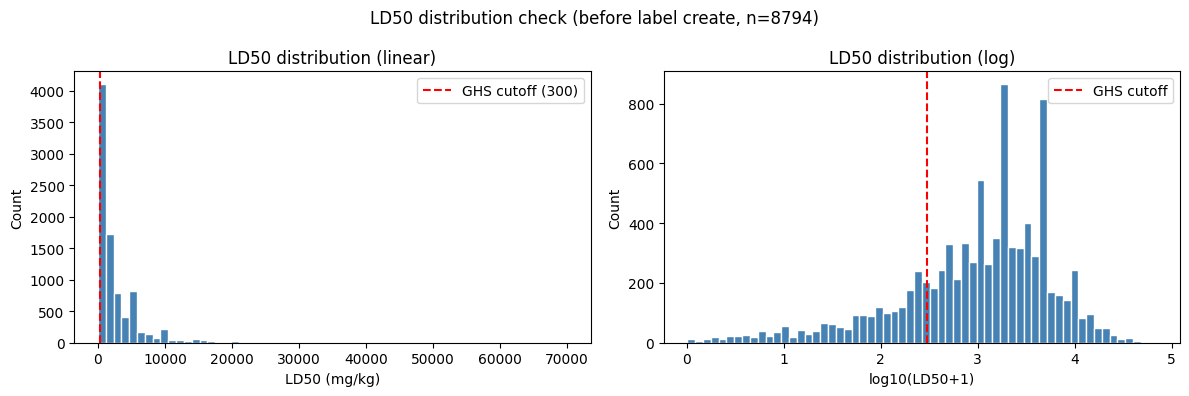

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['LD50_median'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(300, color='red', linestyle='--', label='GHS cutoff (300)')
axes[0].set(title='LD50 distribution (linear)', xlabel='LD50 (mg/kg)', ylabel='Count')
axes[0].legend()

axes[1].hist(np.log10(df['LD50_median']+1), bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(np.log10(300), color='red', linestyle='--', label='GHS cutoff')
axes[1].set(title='LD50 distribution (log)', xlabel='log10(LD50+1)', ylabel='Count')
axes[1].legend()

plt.suptitle(f'LD50 distribution check (before label create, n={len(df)})')
plt.tight_layout()
plt.show()

데이터 분포를 봤을 때, 왼쪽(Toxic)이 오른쪽(Non-toxic)보다 훨씬 적다. 
(이후 모델 만들 때, accuracy뿐만 아니라 Balanced Accuracy, ROC-AUC 등 다른 지표도 봐야할 듯)

In [4]:
df['label'] = (df['LD50_median'] <= 300).astype(int)
print(f'label 분포: {df["label"].value_counts().to_dict()}')

label 분포: {0: 6849, 1: 1945}


In [5]:
#SMILES 유효성 분류
def check_smiles(smi):
    if '.' in str(smi): return 'dot'
    if Chem.MolFromSmiles(str(smi)) is None: return 'invalid'
    return 'valid'

df['status'] = df['SMILES'].apply(check_smiles)
print(df['status'].value_counts())

status
valid      7309
dot        1481
invalid       4
Name: count, dtype: int64


In [6]:
#PubChem에서 SMILES 보충
def fetch_smiles_pubchem(casrn):
    url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{casrn}/property/CanonicalSMILES/JSON'
    try:
        r = requests.get(url, timeout=5)
        if r.status_code == 200:
            return r.json()['PropertyTable']['Properties'][0]['CanonicalSMILES']
    except:
        pass
    return None

def is_valid_single(smi):
    if smi is None or '.' in str(smi): return False
    return Chem.MolFromSmiles(str(smi)) is not None

target = df[df['status'] != 'valid']
print(f'PubChem 조회 대상: {len(target)}개')

for i, (idx, row) in enumerate(target.iterrows()):
    new_smi = fetch_smiles_pubchem(row['CASRN'])
    if is_valid_single(new_smi):
        df.at[idx, 'SMILES'] = new_smi
        df.at[idx, 'status'] = 'valid'
    if (i+1) % 100 == 0:
        print(f'  {i+1}/{len(target)} 완료')
    time.sleep(0.2)

df = df[df['status'] == 'valid'].reset_index(drop=True)
print(f'최종 유효 화합물: {len(df)}')

PubChem 조회 대상: 1485개
  100/1485 완료
  200/1485 완료
  300/1485 완료
  400/1485 완료
  500/1485 완료
  600/1485 완료
  700/1485 완료
  800/1485 완료
  900/1485 완료
  1000/1485 완료
  1100/1485 완료
  1200/1485 완료
  1300/1485 완료
  1400/1485 완료
최종 유효 화합물: 7309


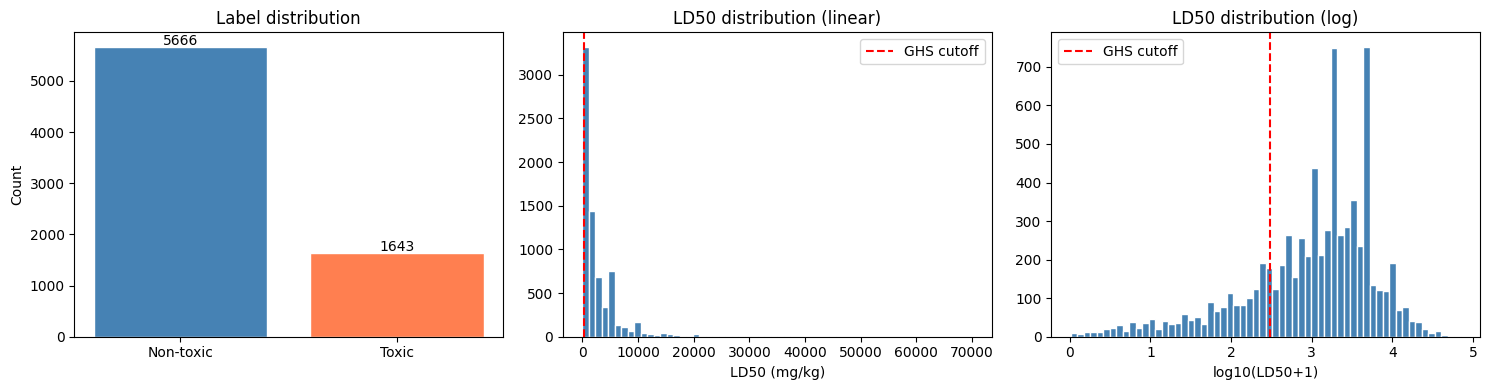

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 라벨 비율
vc = df['label'].value_counts()
axes[0].bar(['Non-toxic','Toxic'], vc.values, color=['steelblue','coral'], edgecolor='white')
for i, v in enumerate(vc.values): axes[0].text(i, v+30, str(v), ha='center')
axes[0].set(title='Label distribution', ylabel='Count')

# LD50 linear
axes[1].hist(df['LD50_median'], bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(300, color='red', linestyle='--', label='GHS cutoff')
axes[1].set(title='LD50 distribution (linear)', xlabel='LD50 (mg/kg)')
axes[1].legend()

# LD50 log
axes[2].hist(np.log10(df['LD50_median']+1), bins=60, color='steelblue', edgecolor='white')
axes[2].axvline(np.log10(300), color='red', linestyle='--', label='GHS cutoff')
axes[2].set(title='LD50 distribution (log)', xlabel='log10(LD50+1)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
desc_fns = Descriptors.descList
gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

rows = []
for smi in df['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    d2d   = [fn(mol) for _, fn in desc_fns]
    ecfp4 = list(gen.GetFingerprint(mol))
    maccs = list(rdMolDescriptors.GetMACCSKeysFingerprint(mol))
    rows.append(d2d + ecfp4 + maccs)

cols = ([n for n,_ in desc_fns]
      + [f'ECFP4_{i}' for i in range(2048)]
      + [f'MACCS_{i}' for i in range(167)])

df_desc = pd.DataFrame(rows, columns=cols)
print('descriptor shape:', df_desc.shape)

descriptor shape: (7309, 2432)


In [9]:
df_final = pd.concat(
    [df[['CASRN','Chemical_Name','SMILES','LD50_median','label']], df_desc],
    axis=1
)
df_final.to_csv('final_dataset_descriptors.csv', index=False)
print('저장 완료:', df_final.shape)

저장 완료: (7309, 2437)


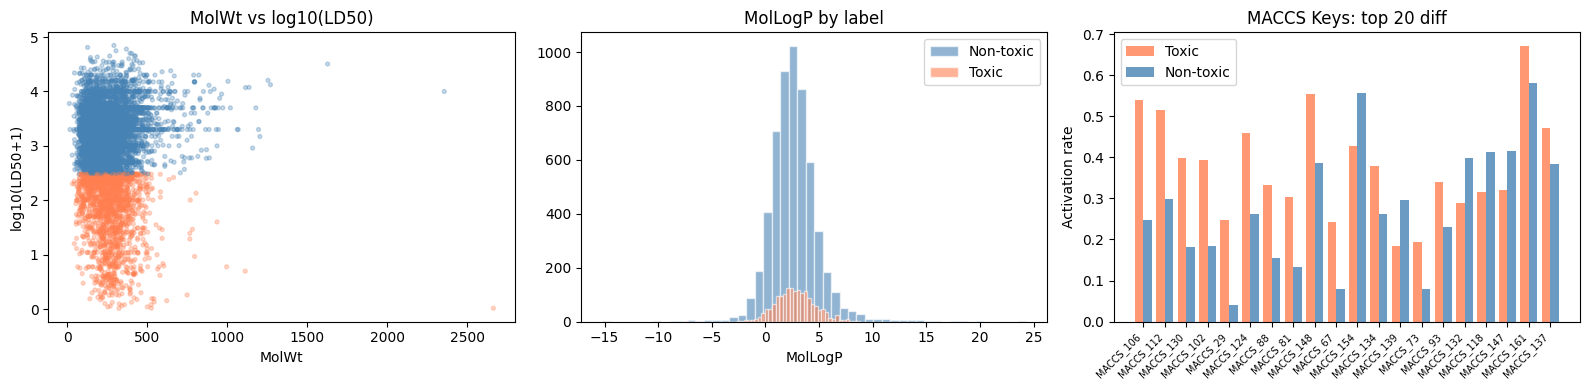

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = df['label'].map({0:'steelblue', 1:'coral'})
axes[0].scatter(df_desc['MolWt'], np.log10(df['LD50_median']+1),
                c=colors, alpha=0.3, s=8)
axes[0].set(title='MolWt vs log10(LD50)', xlabel='MolWt', ylabel='log10(LD50+1)')

for lb, col, nm in [(0,'steelblue','Non-toxic'),(1,'coral','Toxic')]:
    axes[1].hist(df_desc.loc[df['label']==lb,'MolLogP'], bins=50,
                 alpha=0.6, color=col, label=nm, edgecolor='white')
axes[1].set(title='MolLogP by label', xlabel='MolLogP')
axes[1].legend()

maccs_cols = [c for c in df_final.columns if c.startswith('MACCS')]
diff = (df_final[df_final['label']==1][maccs_cols].mean()
      - df_final[df_final['label']==0][maccs_cols].mean()).abs()
top20 = diff.nlargest(20)
x = np.arange(20)
axes[2].bar(x-0.2, df_final[df_final['label']==1][top20.index].mean(),
            0.4, color='coral', alpha=0.8, label='Toxic')
axes[2].bar(x+0.2, df_final[df_final['label']==0][top20.index].mean(),
            0.4, color='steelblue', alpha=0.8, label='Non-toxic')
axes[2].set_xticks(x)
axes[2].set_xticklabels(top20.index, rotation=45, ha='right', fontsize=7)
axes[2].set(title='MACCS Keys: top 20 diff', ylabel='Activation rate')
axes[2].legend()

plt.tight_layout()
plt.show()

MACCS_161에서 차이가 가장 크다 — 방향족 질소(aromatic nitrogen) 존재 여부. 독성 화합물에 이 구조가 더 자주 나타난다는 뜻.

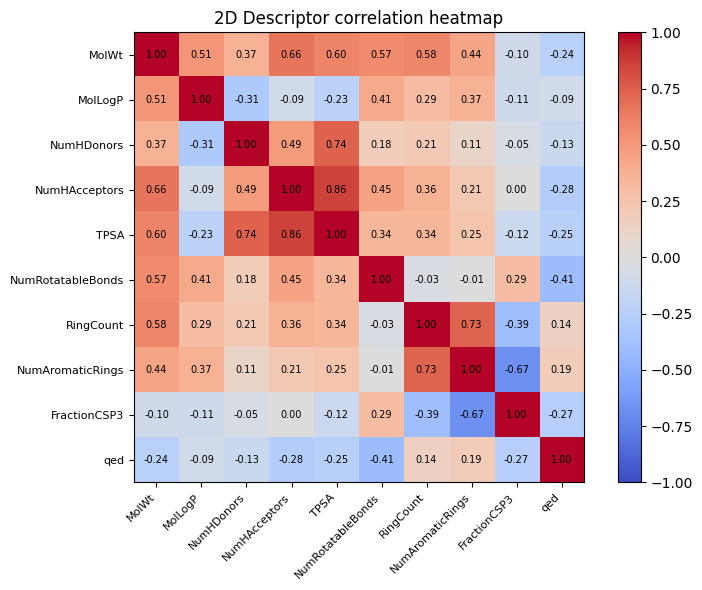

In [11]:
top_desc = ['MolWt','MolLogP','NumHDonors','NumHAcceptors',
            'TPSA','NumRotatableBonds','RingCount','NumAromaticRings','FractionCSP3','qed']
corr = df_desc[top_desc].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(top_desc, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(top_desc, fontsize=8)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('2D Descriptor correlation heatmap')
plt.tight_layout()
plt.show()